# Meshing

This notebook is used to develop the meshing tools necessary for this project. The components of this task are as follows.

- Efficiently read in a fort.14 file
- Filter the mesh to the sub-region of interest.
- Preserve boundary segments for use in the FEniCSx solver.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import adcircxtools as at
import adios4dolfinx as adx
import basix.ufl
import cmocean
import dolfinx as dx
import dolfinx.plot
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri
import pyvista as pv
import scipy.interpolate
import scipy.spatial
import ufl

## Read in fort.14

In [3]:
adcirc_mesh = at.mesh.ADCIRCMesh.from_fort_14('120m_cut.14')
mesh = at.mesh.Mesh.from_ADCIRCMesh(adcirc_mesh)

## Filter to desired subregion

In [4]:
# The center of a circular filter
# Location of Port Aransas
pa_lon = -97.0611 # deg
pa_lat = 27.8339 # deg
radius_earth = 6371.0 # km
arcradius_main = 10.0 # km
arcradius_interp = arcradius_main + 2.0 # km, for dp/eta/v

In [5]:
# Define a filter callable
filter_main = lambda lon, lat: np.deg2rad(at.geometry.central_angle(
    pa_lon,
    pa_lat,
    lon,
    lat,
    use_deg=True
)) * radius_earth < arcradius_main

In [6]:
# Filter nodes within certain arclength of PA
mesh_main, node_map_main, element_map_main = mesh.filter_by_coordinates(filter_main)

In [7]:
# Define triangulation for interpolation and visualization
triangulation_main = matplotlib.tri.Triangulation(
    mesh_main.coordinates[:, 0],
    mesh_main.coordinates[:, 1],
    mesh_main.elements
)

In [8]:
# Define a filter callable
filter_interp = lambda lon, lat: np.deg2rad(at.geometry.central_angle(
    pa_lon,
    pa_lat,
    lon,
    lat,
    use_deg=True
)) * radius_earth < arcradius_interp

In [9]:
# Filter nodes within certain arclength of PA
mesh_interp, node_map_interp, element_map_interp = mesh.filter_by_coordinates(filter_interp)

In [10]:
# Define triangulation for interpolation and visualization
triangulation_interp = matplotlib.tri.Triangulation(
    mesh_interp.coordinates[:, 0],
    mesh_interp.coordinates[:, 1],
    mesh_interp.elements
)

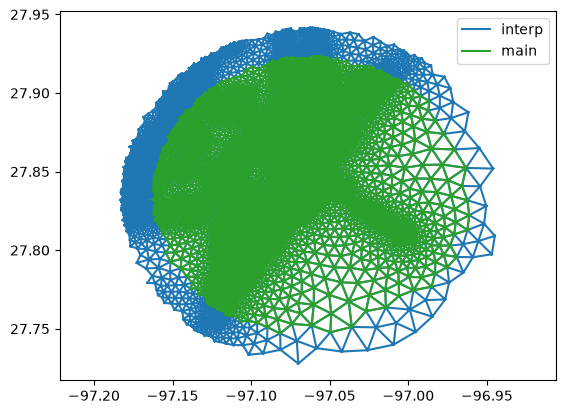

In [11]:
# Check that the interpolataion mesh has a margin around the main mesh
fig, ax = plt.subplots()
ax.triplot(triangulation_interp, label='interp')
ax.triplot(triangulation_main, label='main')
ax.legend()
ax.set_aspect('equal', adjustable='datalim')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


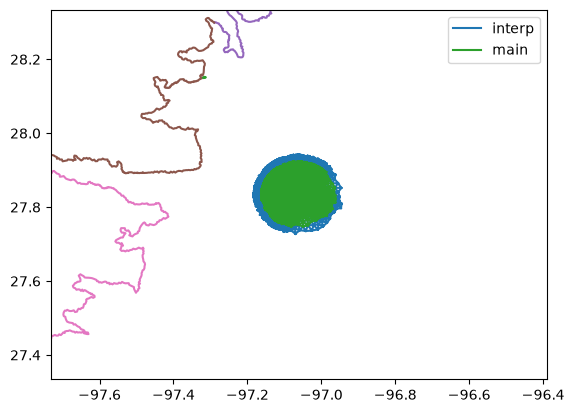

In [12]:
# Show mesh boundaries as well
# None intersect with the study area
fig, ax = plt.subplots()
ax.triplot(triangulation_interp, label='interp')
ax.triplot(triangulation_main, label='main')
ax.legend()
ax.set_aspect('equal', adjustable='datalim')
for k in range(adcirc_mesh.NOPE):
    ax.plot(
        adcirc_mesh.X[adcirc_mesh.NBDV[k] - 1],
        adcirc_mesh.Y[adcirc_mesh.NBDV[k] - 1],
        color='r'
    )
for k in range(adcirc_mesh.NBOU):
    ax.plot(
        adcirc_mesh.X[adcirc_mesh.NBVV[k] - 1],
        adcirc_mesh.Y[adcirc_mesh.NBVV[k] - 1]
    )
ax.set_xlim((pa_lon - 0.5, pa_lon + 0.5))
ax.set_ylim((pa_lat - 0.5, pa_lat + 0.5))
ax.set_aspect('equal')

## Create FEniCSx mesh

In [13]:
# Define simple triangular mesh from the coordinates and elements
ufl_tri = ufl.Mesh(basix.ufl.element('Lagrange', 'triangle', 1, shape=(2,)))
domain = dx.mesh.create_mesh(
    MPI.COMM_WORLD,
    cells=mesh_main.elements,
    x=mesh_main.coordinates,
    e=ufl_tri
)

## Create bathymetry function

In [15]:
# Set up interpolation function for bathymetry
bathymetry_interpolator = matplotlib.tri.LinearTriInterpolator(
    triangulation_interp,
    adcirc_mesh.DP[node_map_interp != -1]
)
def bathy(x):
    return bathymetry_interpolator(x[0], x[1])

In [16]:
# Create continuous linear bathymetry function
V = dx.fem.functionspace(domain, ('Lagrange', 1))
dp = dx.fem.Function(V)
dp.interpolate(bathy)

/var/folders/nc/8r3mn3bn43b7lyftplq0rtrc0000gn/T/ipykernel_53603/3480417900.py:14: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


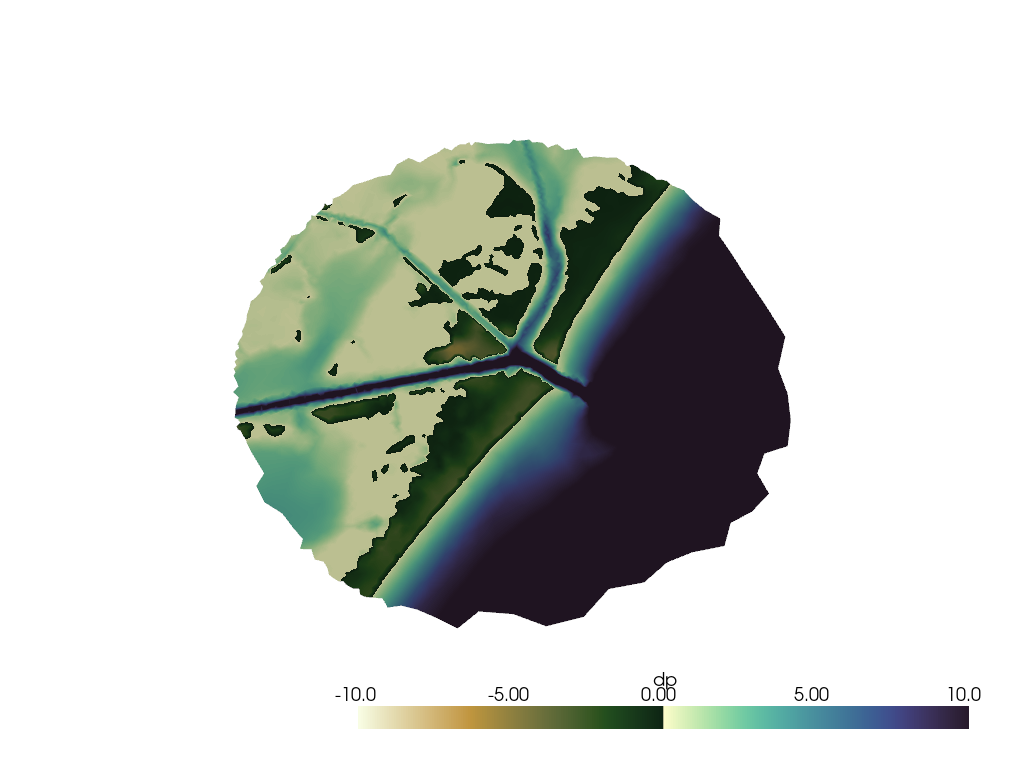

In [20]:
# Visualization to check
topology, cell_types, geometry = dx.plot.vtk_mesh(V)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)
grid.point_data['dp'] = dp.x.array.real
plotter = pv.Plotter()
plotter.add_mesh(
    grid,
    scalars='dp',
    cmap=cmocean.cm.topo.reversed(),
    clim=[-10.0, 10.0],
    show_edges=False
)
plotter.view_xy()
plotter.show()

## Save all data structures

In [22]:
adx.write_mesh('port_aransas.bp', domain)

In [24]:
adx.write_function('port_aransas.bp', dp)

In [25]:
np.save('main_coordinates.npy', mesh_main.coordinates)
np.save('main_elements.npy', mesh_main.elements)
np.save('main_node_map.npy', node_map_main)
np.save('main_element_map.npy', element_map_main)
np.save('interp_coordinates.npy', mesh_interp.coordinates)
np.save('interp_elements.npy', mesh_interp.elements)
np.save('interp_node_map.npy', node_map_interp)
np.save('interp_element_map.npy', element_map_interp)